# Chapter 9: Machine Learning Intro 1

In [2]:
%reset
low_memory=False
import matplotlib.image as img
import matplotlib.pyplot as plt

import copy
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from os import listdir
from sklearn.model_selection import train_test_split
import seaborn as sns; sns.set()
from sklearn import metrics

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


## 9.1 Introduction & Problem Setting

Let's put everything to the test! Starting from a raw dataset, create a model and evualuate it's performance. After that, perform some actual data processing to see if your results change!

Your goal is to predict the spectral class of a new star. You will be given a dataset containing metrics such as size, colour, temperature, ... of different stars to start with. The dataset contains the following collumns:

- Temperature (K): Absolute Temperature (in K)
- Luminosity (L/Lo): Relative Luminosity (L/Lo)
- Radius (R/Ro): Relative Radius (R/Ro)
- Absolute magnitude (Mv): Absolute Magnitude (Mv)
- Star category: Star Category (Red Dwarf, Brown Dwarf, White Dwarf, Main Sequence , SuperGiants, HyperGiants)
- Star color: Star Color (white,Red,Blue,Yellow,yellow-orange etc)
- Spectral Class: Spectral Class (O,B,A,F,G,K,M)
- Spectral Type: Spectral Class encoded as integers

Lo = 3.828 x 10^26 Watts (Avg Luminosity of Sun)
Ro = 6.9551 x 10^8 m (Avg Radius of Sun)

## 9.2 Creating and evaluating your first model

Create your first model on the data. Consider the column 'Spectral Class' as the Y variable. Do not modify the data just yet, use the data as it is provided. Which columns are suitable for your model out of the box? Why? Only use those columns as X.

Evaluate your model by creating a heatmap of you predictions. Remember to only use 25% of your total dataset for this!

**Make sure to avoid a data leak.**

*Hint: you can use the RandomForest model from the notebook as a starting model.*

In [86]:
stars = pd.read_csv ('Stars.csv')
stars.head()

,Temperature (K),Luminosity (L/Lo),Radius (R/Ro),Absolute magnitude (Mv),Star category,Star color,Spectral Class,Spectral Type
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M,5
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M,5
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M,5
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M,5
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M,5


In [87]:
stars.dtypes

Temperature (K)              int64
Luminosity (L/Lo)          float64
Radius (R/Ro)              float64
Absolute magnitude (Mv)    float64
Star category               object
Star color                  object
Spectral Class              object
Spectral Type                int64
dtype: object

The columns 'Temperature (K)', 'Luminosity (L/Lo)', 'Radius (R/Ro)', 'Absolute magnitude (Mv)' and 'Spectral Type' are integers, so we can use these columns to train our model.

In [88]:
X = stars[['Temperature (K)', 'Luminosity (L/Lo)', 'Radius (R/Ro)', 'Absolute magnitude (Mv)', 'Spectral Type']]
Y = stars['Spectral Class']

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.25) 

In [89]:
X_train.shape

(180, 5)

In [90]:
X_test.shape

(60, 5)

In [91]:
ML_model = RandomForestClassifier()
ML_model.fit(X_train, y_train)
ML_model

RandomForestClassifier()

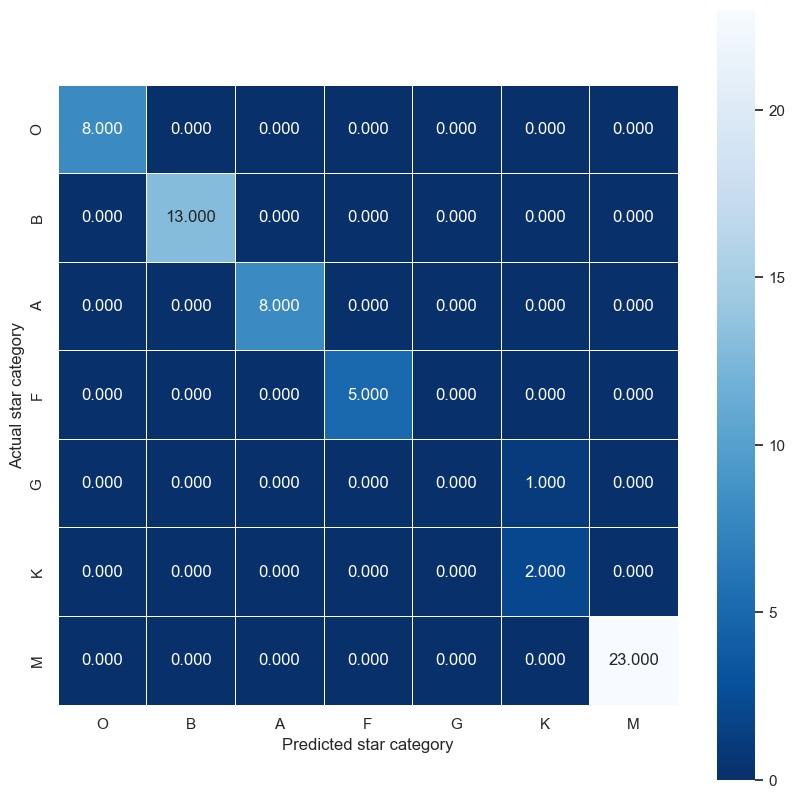

In [92]:
y_pred = ML_model.predict(X_test)

labels = ['O', 'B', 'A', 'F', 'G', 'K', 'M']
plt.figure(figsize=(10,10))
sns.heatmap(metrics.confusion_matrix(y_test, y_pred, labels=labels),
            annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r',
            xticklabels=labels, yticklabels=labels);
plt.ylabel('Actual star category');
plt.xlabel('Predicted star category');

There are two conclusions we can make from this.

First, there seem to be no 'G' stars in our test dataset. That is possible, as we don't know which records are included in the 25%

Second, the model appears to make only a single mistake. This is highly suspicious and may indicate a data leak. When looking at the input variables, we can identify the issue: the column 'Spectral Type'. While this columns is an integer and therefor suitable for machine learning, we have to think about the meaning of the variable. In this case, it contains the same value as Spactral Class (our Y variable), but just encoded as integers! By including this variable in our X, we have introduced a data leak.

Let's fix this by creating a new model without the Spectral Type variable.

In [99]:
X = stars[['Temperature (K)', 'Luminosity (L/Lo)', 'Radius (R/Ro)', 'Absolute magnitude (Mv)']]
Y = stars['Spectral Class']

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.5) 

In [100]:
X_train.shape

(120, 4)

In [101]:
X_test.shape

(120, 4)

In [102]:
ML_model = RandomForestClassifier()
ML_model.fit(X_train, y_train)
ML_model

RandomForestClassifier()

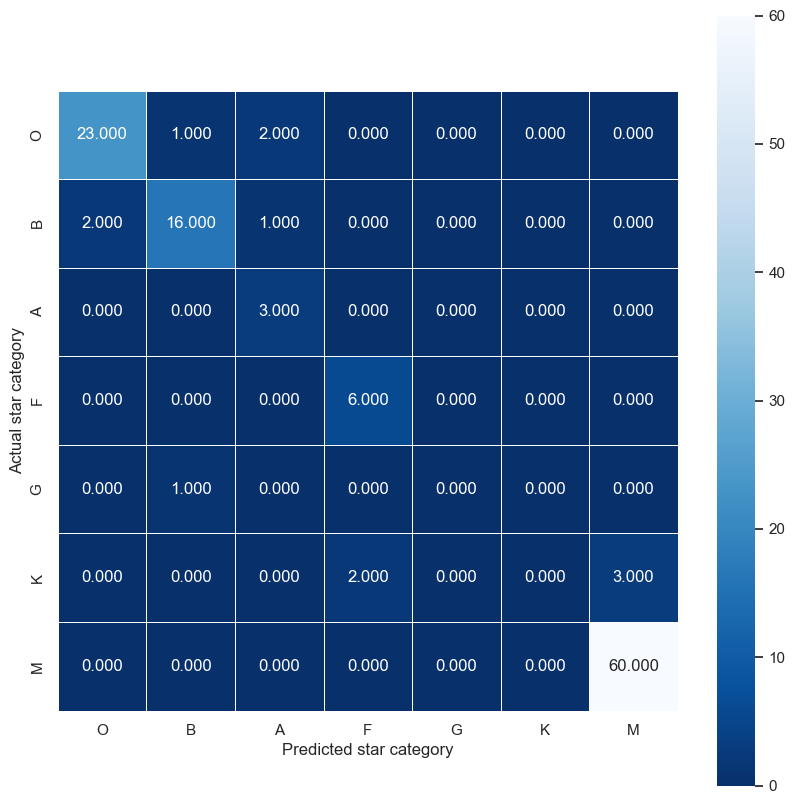

In [103]:
y_pred = ML_model.predict(X_test)

labels = ['O', 'B', 'A', 'F', 'G', 'K', 'M']
plt.figure(figsize=(10,10))
sns.heatmap(metrics.confusion_matrix(y_test, y_pred, labels=labels),
            annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r',
            xticklabels=labels, yticklabels=labels);
plt.ylabel('Actual star category');
plt.xlabel('Predicted star category');

While a heatmap is useful, it is not always clear which model is better when comparing several of them. That's why we generally use an **accuracy score**. This score tells us how well the model is performing, and how many predictions it has correct. Calculate the accuracy score of your model and interpret it. Is your model any good?

**https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#sklearn.ensemble.RandomForestClassifier.score**
```
score = model.score()
```

In [104]:
ML_model.score(X_test, y_test)

0.9

We have an accuracy score of 0.9. This means that 90% of our predictions are correct, which is great!

## 9.3: Data Processing

Now look into the data. Answer the following questions:

- Are there missing values?
- How is the data distributed?
- Is any of the data correlated?

In [106]:
stars.describe()

,Temperature (K),Luminosity (L/Lo),Radius (R/Ro),Absolute magnitude (Mv),Spectral Type
count,240.000000,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396,3.758333
std,9552.425037,179432.244940,517.155763,10.532512,2.090007
min,1939.000000,0.000080,0.008400,-11.920000,0.000000
25%,3344.250000,0.000865,0.102750,-6.232500,1.000000
50%,5776.000000,0.070500,0.762500,8.313000,5.000000
75%,15055.500000,198050.000000,42.750000,13.697500,5.000000
max,40000.000000,849420.000000,1948.500000,20.060000,6.000000


It appears there are no missing values in the columns we used so far. We lack the proper knowledge to interpret the min and max values of these columns, so we will assume they are indeed correct.

In [107]:
stars.isna().describe()

,Temperature (K),Luminosity (L/Lo),Radius (R/Ro),Absolute magnitude (Mv),Star category,Star color,Spectral Class,Spectral Type
count,240,240,240,240,240,240,240,240
unique,1,1,1,1,1,1,1,1
top,False,False,False,False,False,False,False,False
freq,240,240,240,240,240,240,240,240


The remaining columns also do not contain any missing values.

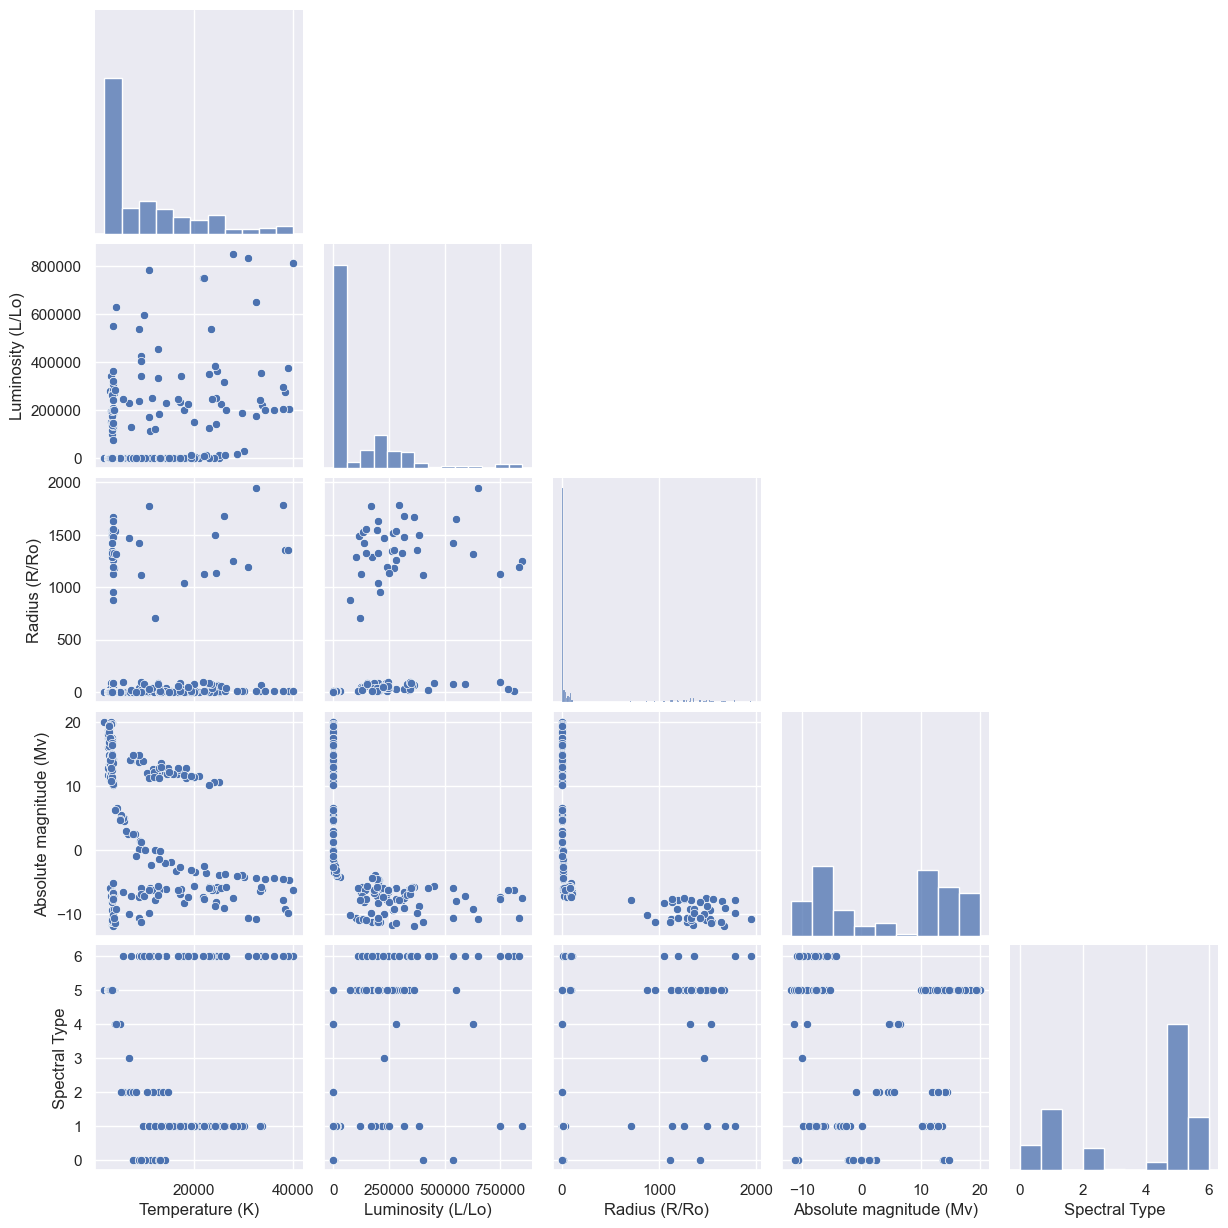

In [109]:
sns.pairplot(stars, vars=['Temperature (K)', 'Luminosity (L/Lo)', 'Radius (R/Ro)', 'Absolute magnitude (Mv)', 'Spectral Type'], corner=True, kind="scatter", diag_kind="hist")

We can see that most data is not evenly distributed, and tends to lean to the lower values. This indicates outliers in higher values.

Except for Spectral type, which shows more high values. Then again, this is simply a mapping of values to certain spectral classes at random and thus holds no real meaning. The same goes for the correlations with Spectral type, as can be seen in the plots where there clearly is no correlation.

We can see that absolute magnitude has some negative correlations with the other columns.

Based on your answers above, perform the needed data processing on the dataset. Some topics to take into consideration:

- Imputing/dropping missing values
- Centralization/normalization
- One-hot encoding
- ...

Drop columns which can lead to a data leak.

In [133]:
stars_cleaned = stars.drop('Spectral Type', axis=1)

In [134]:
def normalizeData(column):
    data_to_scale = column.values.reshape((len(column), 1))
    scaler = preprocessing.StandardScaler()
    scaler = scaler.fit(data_to_scale)
    data_normalized = scaler.transform(data_to_scale)
    return data_normalized

In [135]:
stars_cleaned['Temperature (K)'] = normalizeData(stars['Temperature (K)'])
stars_cleaned['Luminosity (L/Lo)'] = normalizeData(stars['Luminosity (L/Lo)'])
stars_cleaned['Radius (R/Ro)'] = normalizeData(stars['Radius (R/Ro)'])
stars_cleaned['Absolute magnitude (Mv)'] = normalizeData(stars['Absolute magnitude (Mv)'])

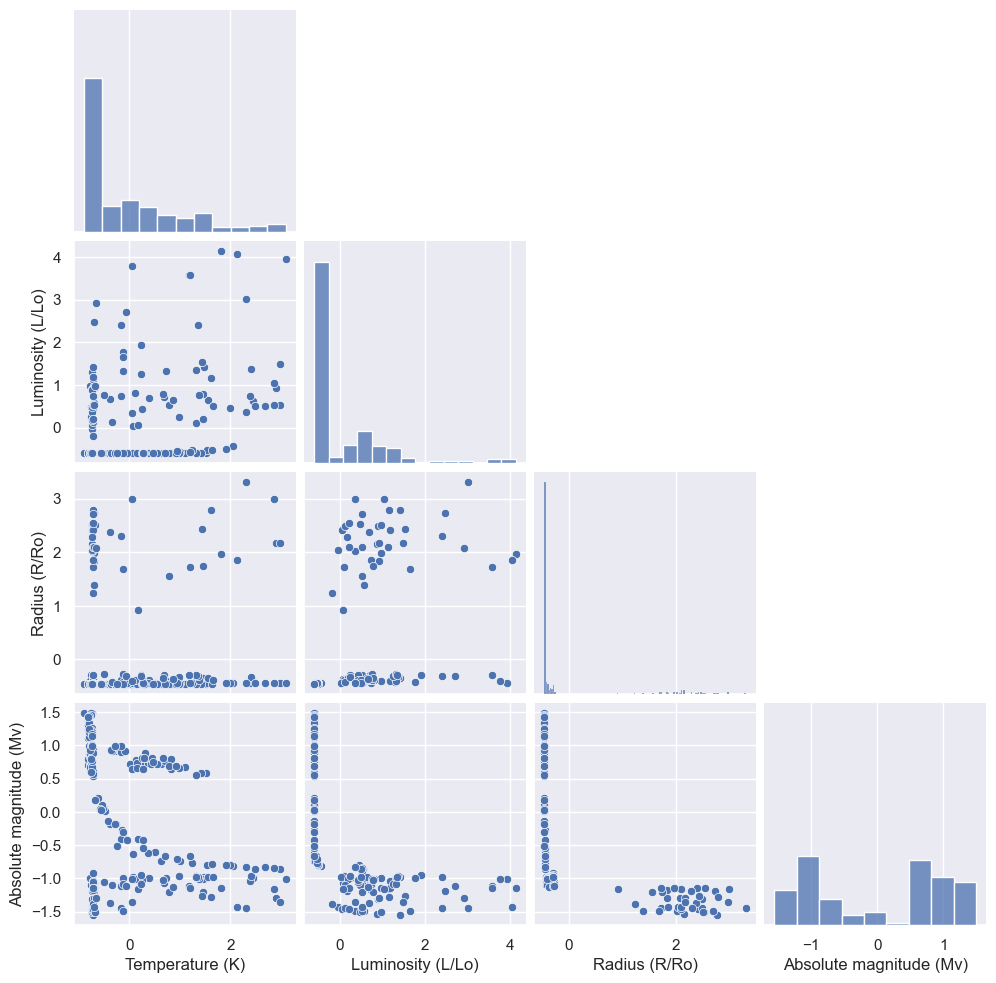

In [136]:
sns.pairplot(stars_cleaned, vars=['Temperature (K)', 'Luminosity (L/Lo)', 'Radius (R/Ro)', 'Absolute magnitude (Mv)'], corner=True, kind="scatter", diag_kind="hist")

In [137]:
stars_cleaned = pd.get_dummies(stars_cleaned, columns = ['Star category', 'Star color'], dtype='int')
stars_cleaned.head()

,Temperature (K),Luminosity (L/Lo),Radius (R/Ro),Absolute magnitude (Mv),Spectral Class,Star category_Brown Dwarf,Star category_Hypergiant,Star category_Main Sequence,Star category_Red Dwarf,Star category_Supergiant,...,Star color_Pale yellow orange,Star color_Red,Star color_White,Star color_White-Yellow,Star color_Whitish,Star color_Yellowish,Star color_Yellowish White,Star color_white,Star color_yellow-white,Star color_yellowish
0,-0.779382,-0.598624,-0.459210,1.116745,M,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,-0.782110,-0.598624,-0.459241,1.162414,M,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
2,-0.828477,-0.598624,-0.459342,1.362213,M,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,-0.807496,-0.598624,-0.459229,1.167171,M,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,-0.897819,-0.598624,-0.459340,1.491607,M,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


Create a new model with your processed dataset. Evaluate it again in the same way as your original model (25% as testing data, heatmap, accuracy score) and compare. What changed?

In [140]:
X = stars_cleaned.drop('Spectral Class', axis=1)
Y = stars_cleaned['Spectral Class']

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.25) 

In [141]:
X_train.shape

(180, 29)

In [142]:
X_test.shape

(60, 29)

In [143]:
ML_model = RandomForestClassifier()
ML_model.fit(X_train, y_train)
ML_model

RandomForestClassifier()

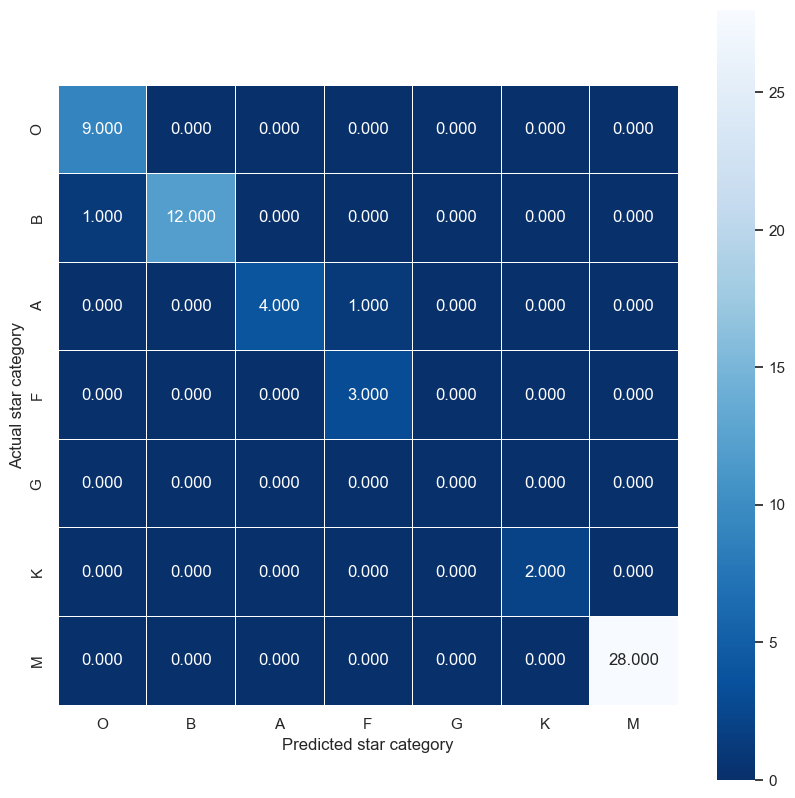

In [144]:
y_pred = ML_model.predict(X_test)

labels = ['O', 'B', 'A', 'F', 'G', 'K', 'M']
plt.figure(figsize=(10,10))
sns.heatmap(metrics.confusion_matrix(y_test, y_pred, labels=labels),
            annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r',
            xticklabels=labels, yticklabels=labels);
plt.ylabel('Actual star category');
plt.xlabel('Predicted star category');

In [146]:
ML_model.score(X_test, y_test)

0.9666666666666667

We now have an accuracy of 0.97, which means that 97% of our predictions are correct. This is a big improvement! The only downside we now have is that we ended up with 29 columns instead of 4. This is a lot more. In later courses you will be seeing some advanced tricks to reduce this number, but next week we will also be diving into that a little bit ;)